In [59]:
from pathlib import Path
import numpy as np
import polars as pl
from sklearn.preprocessing import LabelEncoder
from src.tennis import fetch_jeff_sackmann_atp_data, read_tennis_data

In [60]:
files = fetch_jeff_sackmann_atp_data(dest_dir="data/atp_raw", start_year=2000, end_year=2025)

In [61]:
df_tennis = read_tennis_data(files)

In [73]:
df_tennis = df_tennis.with_columns([
    df_tennis["tourney_date"].cast(str).str.strptime(pl.Date, "%Y%m%d").alias("date"),
    (df_tennis['w_1stWon'] + df_tennis['w_2ndWon']).alias("w_serve_won"),
    (df_tennis['l_1stWon'] + df_tennis['l_2ndWon']).alias("l_serve_won"),
    ])

df_tennis = df_tennis.filter(pl.col("tourney_level").is_in(["G", "M", "A"]))

In [64]:
# drop davis cup (D)
# drop final/season ending events (F) 
df_tennis['tourney_level'].value_counts()

tourney_level,count
str,u32
"""A""",40847
"""M""",13998
"""G""",12573


In [65]:
# create a link between winner_id -> winner_name, and loser_id -> loser_name. So that I can have a dataframe of unique player ids and names
def get_player_id_name_df(df: pl.DataFrame) -> pl.DataFrame:
    winner_df = df.select([
        pl.col("winner_id").alias("player_id"),
        pl.col("winner_name").alias("player_name")
    ]).unique()

    loser_df = df.select([
        pl.col("loser_id").alias("player_id"),
        pl.col("loser_name").alias("player_name")
    ]).unique()

    player_df = pl.concat([winner_df, loser_df]).unique().sort("player_id")

    return player_df

In [74]:
link_player_df = get_player_id_name_df(df_tennis)

In [75]:
link_player_df

player_id,player_name
i64,str
100644,"""Alexander Zverev"""
101086,"""Ronald Agenor"""
101150,"""Gianluca Pozzi"""
101167,"""Jaime Cortes"""
101185,"""Mark Woodforde"""
…,…
212021,"""Martin Landaluce"""
212044,"""Yi Zhou"""
212063,"""Matej Dodig"""


In [76]:
server_names = np.concatenate([
    df_tennis['winner_id'].to_numpy(),
    df_tennis['loser_id'].to_numpy()
])

returner_names = np.concatenate([
    df_tennis['loser_id'].to_numpy(),
    df_tennis['winner_id'].to_numpy()
])

In [77]:
player_id_encoder = LabelEncoder()

server_ids = player_id_encoder.fit_transform(server_names)
returner_ids = player_id_encoder.transform(returner_names)

In [78]:
df_tennis.columns

['tourney_id',
 'tourney_name',
 'surface',
 'draw_size',
 'tourney_level',
 'tourney_date',
 'match_num',
 'winner_id',
 'winner_seed',
 'winner_entry',
 'winner_name',
 'winner_hand',
 'winner_ht',
 'winner_ioc',
 'winner_age',
 'loser_id',
 'loser_seed',
 'loser_entry',
 'loser_name',
 'loser_hand',
 'loser_ht',
 'loser_ioc',
 'loser_age',
 'score',
 'best_of',
 'round',
 'minutes',
 'w_ace',
 'w_df',
 'w_svpt',
 'w_1stIn',
 'w_1stWon',
 'w_2ndWon',
 'w_SvGms',
 'w_bpSaved',
 'w_bpFaced',
 'l_ace',
 'l_df',
 'l_svpt',
 'l_1stIn',
 'l_1stWon',
 'l_2ndWon',
 'l_SvGms',
 'l_bpSaved',
 'l_bpFaced',
 'winner_rank',
 'winner_rank_points',
 'loser_rank',
 'loser_rank_points',
 'date',
 'w_serve_won',
 'l_seve_won',
 'l_serve_won']

In [79]:
winner_serve_won = df_tennis['w_serve_won'].to_numpy()
winner_serve_total = df_tennis['w_svpt'].to_numpy()
loser_serve_won = df_tennis['l_serve_won'].to_numpy()
loser_serve_total = df_tennis['l_svpt'].to_numpy()

# Basic Hierarchial Regression 

Note: This work is inspired and built off some tennis bayesian work I've seen by Martin Ingram. My goal here is to get more fluent with numpyro. 

Link 1: https://martiningram.github.io/historical-serve-return/  
Link 2: https://martiningram.github.io/papers/bayes_point_based.pdf  

In [80]:
from jax import random 
import numpyro 
import numpyro.distributions as dist

In [81]:
def basic_serve_return_model(X_intercept, n_players, server_idx, returner_idx, serve_attempts, serve_pts_won):
    """
    Hierarchical model with separate serve and return effects for each player.
    Args:
        Intercept: prior mean for intercept
        players_n: number of players
        server_idx: array of server indices (0-based)
        returner_idx: array of returner indices (0-based)
        y: binary outcome (1=server wins point, 0=loses)
    """
    # Intercept
    intercept = numpyro.sample("intercept", dist.Normal(X_intercept, 1))

    # Random Effects
    # Server
    mu_server = numpyro.sample("mu_server", dist.Normal(0, 1))
    sigma_server = numpyro.sample("sigma_server", dist.HalfNormal(1))
    with numpyro.plate("players_server", n_players):
        player_server = numpyro.sample("player_server", dist.Normal(mu_server, sigma_server))


    # Returner
    mu_return = numpyro.sample("mu_ret", dist.Normal(0, 1))
    sigma_return = numpyro.sample("sigma_ret", dist.HalfNormal(1))
    with numpyro.plate("players_returner", n_players):
        player_return = numpyro.sample("player_ret", dist.Normal(mu_return, sigma_return))

    # Combine logits
    logits = intercept + player_server[server_idx] - player_return[returner_idx]

    # Likelihood
    numpyro.sample("obs", dist.Binomial(total_count=serve_attempts, logits=logits), obs=serve_pts_won)    

In [82]:
# note define model dict 
# prep the model info from function 
model_dct = {
    'X_intercept': 1,
    'n_players': len(player_id_encoder.classes_),    
    'server_idx': server_ids + 1,
    'returner_idx': returner_ids + 1,
    'serve_attempts': np.concatenate([winner_serve_total, loser_serve_total]).astype(np.int32),
    'serve_pts_won': np.concatenate([winner_serve_won, loser_serve_won]).astype(np.int32)    
}

/var/folders/_7/3hw2lssx4zjb6_p04ljvgyjw0000gn/T/ipykernel_6342/3297196930.py:8: RuntimeWarning: invalid value encountered in cast
  'serve_attempts': np.concatenate([winner_serve_total, loser_serve_total]).astype(np.int32),
/var/folders/_7/3hw2lssx4zjb6_p04ljvgyjw0000gn/T/ipykernel_6342/3297196930.py:9: RuntimeWarning: invalid value encountered in cast
  'serve_pts_won': np.concatenate([winner_serve_won, loser_serve_won]).astype(np.int32)


In [83]:
from src.model_helpers import model_prep_svi, svi_conv_plot
from numpyro.infer import autoguide

In [84]:
svi_iters = 10000
adam_lr = 0.001
# note - use low rank, its faster when we have a lot of records
guide, basic_sv = model_prep_svi(basic_serve_return_model, iterations = svi_iters, lr = adam_lr, 
                                 guide_fn = autoguide.AutoLowRankMultivariateNormal)

In [85]:
basic_sv_results = basic_sv.run(random.PRNGKey(1), svi_iters, **model_dct)

100%|██████████| 10000/10000 [00:22<00:00, 447.31it/s, init loss: 3535080.0000, avg. loss [9501-10000]: 430514.3438]



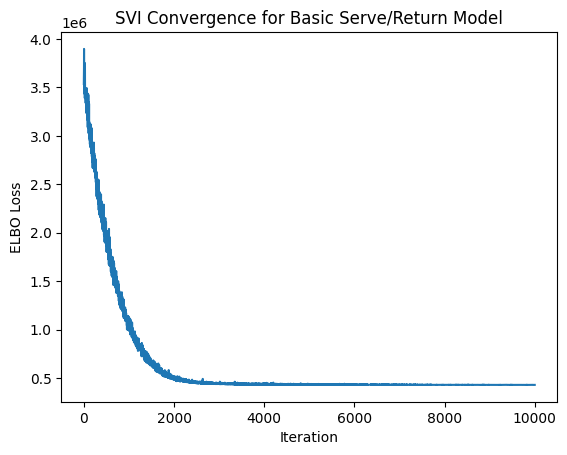

In [86]:
svi_conv_plot(basic_sv_results, 'Basic Serve/Return')

In [87]:
from jax.random import PRNGKey
import polars as pl
import numpy as np

In [88]:
def get_posteriors(guide, params, sample_shape=(5000,), seed=1):
    posteriors = guide.sample_posterior(
        PRNGKey(seed), 
        params, 
        sample_shape=sample_shape
    )
    return posteriors


def posteriors_to_dataframe(posteriors, credible_interval=0.95):
    # Calculate alpha for credible intervals
    alpha = (1 - credible_interval) / 2
    lower_percentile = alpha * 100
    upper_percentile = (1 - alpha) * 100
    
    results = []
    
    for param_name, samples in posteriors.items():
        # Skip internal parameters
        if param_name.startswith("_"):
            continue
        
        # Convert to numpy array
        samples_array = np.array(samples)
        
        # Handle different shapes
        if samples_array.ndim == 1:
            # Single parameter
            results.append({
                'parameter': param_name,
                'mean': float(np.mean(samples_array)),
                'lower_ci': float(np.percentile(samples_array, lower_percentile)),
                'upper_ci': float(np.percentile(samples_array, upper_percentile))
            })
        else:
            # Multiple parameters (e.g., coefficient vector)
            # Flatten all but the first dimension (sample dimension)
            original_shape = samples_array.shape[1:]
            samples_flat = samples_array.reshape(samples_array.shape[0], -1)
            
            for idx in range(samples_flat.shape[1]):
                param_samples = samples_flat[:, idx]
                
                # Create parameter label
                if len(original_shape) == 1:
                    param_label = f"{param_name}[{idx}]"
                else:
                    # Multi-dimensional index
                    multi_idx = np.unravel_index(idx, original_shape)
                    param_label = f"{param_name}{list(multi_idx)}"
                
                results.append({
                    'parameter': param_label,
                    'mean': float(np.mean(param_samples)),
                    'lower_ci': float(np.percentile(param_samples, lower_percentile)),
                    'upper_ci': float(np.percentile(param_samples, upper_percentile))
                })
    
    return pl.DataFrame(results)

In [89]:
posteriors = get_posteriors(guide, basic_sv_results.params, sample_shape=(5000,), seed=1)
#
# Step 2: Create summary dataframe
summary_df = posteriors_to_dataframe(posteriors, credible_interval=0.95)
# print(summary_df)

In [90]:
summary_df.head()

parameter,mean,lower_ci,upper_ci
str,f64,f64,f64
"""intercept""",0.597155,0.579628,0.614465
"""mu_ret""",-0.12433,-0.14502,-0.103327
"""mu_server""",-0.220873,-0.231633,-0.210459
"""player_ret[0]""",-0.121111,-0.396532,0.161287
"""player_ret[1]""",0.097826,0.060718,0.136207


In [96]:
ret_results = summary_df.filter(pl.col("parameter").str.contains("player_ret")).with_columns(
        pl.col("parameter")
        .str.extract(r"\[(\d+)\]", 1)
        .cast(pl.Int64, strict=False)
        .alias("returner_index")
)

player_id_transformed = player_id_encoder.inverse_transform(ret_results['returner_index'])

ret_results = ret_results.with_columns([
    pl.Series(player_id_transformed).alias("player_id")
]).join(link_player_df, on="player_id", how="left")

In [97]:
ret_results

parameter,mean,lower_ci,upper_ci,returner_index,player_id,player_name
str,f64,f64,f64,i64,i64,str
"""player_ret[0]""",-0.121111,-0.396532,0.161287,0,100644,"""Alexander Zverev"""
"""player_ret[1]""",0.097826,0.060718,0.136207,1,101086,"""Ronald Agenor"""
"""player_ret[2]""",-0.094948,-0.184061,-0.0064,2,101150,"""Gianluca Pozzi"""
"""player_ret[3]""",-0.017841,-0.072339,0.036663,3,101167,"""Jaime Cortes"""
"""player_ret[4]""",-0.112428,-0.350507,0.128195,4,101185,"""Mark Woodforde"""
…,…,…,…,…,…,…
"""player_ret[1592]""",-0.248826,-0.456947,-0.034232,1592,212021,"""Martin Landaluce"""
"""player_ret[1593]""",-0.214282,-0.369757,-0.061071,1593,212044,"""Yi Zhou"""
"""player_ret[1594]""",-0.152387,-0.306749,-0.001468,1594,212063,"""Matej Dodig"""


In [94]:
server_results = summary_df.filter(pl.col("parameter").str.contains("player_server")).with_columns(
        pl.col("parameter")
        .str.extract(r"\[(\d+)\]", 1)
        .cast(pl.Int64, strict=False)
        .alias("server_index")
)

server_id_transformed = player_id_encoder.inverse_transform(server_results['server_index'])

server_results = server_results.with_columns([
    pl.Series(server_id_transformed).alias("player_id")
]).join(link_player_df, on="player_id", how="left")

In [95]:
server_results

parameter,mean,lower_ci,upper_ci,server_index,player_id,player_name
str,f64,f64,f64,i64,i64,str
"""player_server[0]""",-0.224603,-0.563518,0.109837,0,100644,"""Alexander Zverev"""
"""player_server[1]""",0.086015,0.061771,0.110486,1,101086,"""Ronald Agenor"""
"""player_server[2]""",-0.323308,-0.411874,-0.238461,2,101150,"""Gianluca Pozzi"""
"""player_server[3]""",-0.176367,-0.22559,-0.125545,3,101167,"""Jaime Cortes"""
"""player_server[4]""",-0.384335,-0.662688,-0.106835,4,101185,"""Mark Woodforde"""
…,…,…,…,…,…,…
"""player_server[1592]""",-0.249199,-0.464076,-0.030836,1592,212021,"""Martin Landaluce"""
"""player_server[1593]""",-0.301623,-0.469109,-0.134374,1593,212044,"""Yi Zhou"""
"""player_server[1594]""",-0.200297,-0.367578,-0.035785,1594,212063,"""Matej Dodig"""


# Hierarchial Regression w/Time Component 

Goal: To get player effects varying over time. 

(1) AR(1) Covariance in MultiVariate Normal    
(2) State Space Model   